In [ ]:
# Install required libraries
!pip install nltk scikit-learn seaborn

import pandas as pd, re, nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Install required libraries
!pip install nltk scikit-learn seaborn

import pandas as pd, re, nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')

!wget https://raw.githubusercontent.com/sethukumaran/Zomato-Dataset-Exploratory-Data-Analysis-using-Python/main/zomato.csv -O zomato.csv
df = pd.read_csv('zomato.csv', encoding='latin-1')

# Print the column names to identify the correct ones
print(df.columns)

# Select the correct columns based on the actual column names
# Using the columns that are available in the dataset
df = df[['Restaurant Name', 'Cuisines', 'Aggregate rating', 'Votes']].dropna(subset=['Cuisines'])

# Rename columns to match your original code's expectations
df = df.rename(columns={
    'Restaurant Name': 'name',
    'Cuisines': 'cuisines',
    'Aggregate rating': 'rate',
    'Votes': 'votes'
})

# Note: The original dataset doesn't have a 'reviews_list' column, so we're skipping that
# If you need review data, you'll need to find a different dataset or source

# Display the first few rows to verify
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--2025-06-22 08:18:25--  https://raw.githubusercontent.com/sethukumaran/Zomato-Dataset-Exploratory-Data-Analysis-using-Python/main/zomato.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2257316 (2.2M) [application/octet-stream]
Saving to: ‘zomato.csv’

zomato.csv          100%[===================>]   2.15M  --.-KB/s    in 0.04s   

2025-06-22 08:18:25 (53.4 MB/s) - ‘zomato.csv’ saved [2257316/2257316]

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK stopwords
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('zomato.csv', encoding='latin-1')

# Select relevant columns
df = df[['Restaurant Name', 'Cuisines', 'Aggregate rating', 'Votes']].dropna()

# Rename columns for consistency
df.columns = ['name', 'cuisines', 'rating', 'votes']

# Display basic info
print(df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Shape:", df.shape)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                     name                          cuisines  rating  votes
0        Le Petit Souffle        French, Japanese, Desserts     4.8    314
1        Izakaya Kikufuji                          Japanese     4.5    591
2  Heat - Edsa Shangri-La  Seafood, Asian, Filipino, Indian     4.4    270
3                    Ooma                   Japanese, Sushi     4.9    365
4             Sambo Kojin                  Japanese, Korean     4.8    229

Missing Values:
 name        0
cuisines    0
rating      0
votes       0
dtype: int64

Data Shape: (9542, 4)


In [ ]:
# Clean cuisines (remove special chars, lowercase)
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))  # Remove special chars
    text = text.lower()  # Convert to lowercase
    return text

df['cuisines_cleaned'] = df['cuisines'].apply(clean_text)

# Remove stopwords (irrelevant words like 'and', 'food')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split(',')
    filtered_words = [word.strip() for word in words if word.strip() not in stop_words]
    return ' '.join(filtered_words)

df['cuisines_processed'] = df['cuisines_cleaned'].apply(remove_stopwords)

print("\nProcessed Cuisine Examples:")
print(df['cuisines_processed'].head())


Processed Cuisine Examples:
0         french japanese desserts
1                         japanese
2    seafood asian filipino indian
3                   japanese sushi
4                  japanese korean
Name: cuisines_processed, dtype: object


In [ ]:
# TF-IDF Vectorization (to convert text into numerical data)
tfidf = TfidfVectorizer(max_features=1000)  # Limit to top 1000 features
cuisine_features = tfidf.fit_transform(df['cuisines_processed'])

print("\nTF-IDF Feature Shape:", cuisine_features.shape)


TF-IDF Feature Shape: (9542, 149)


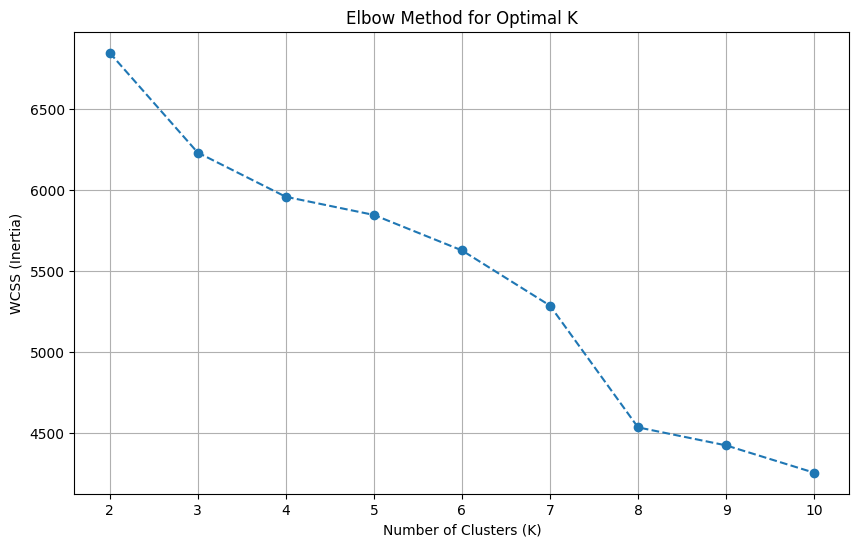

In [ ]:
# Find optimal K using Elbow Method
wcss = []  # Within-Cluster Sum of Squares
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cuisine_features)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid()
plt.show()

In [ ]:
# Apply K-Means with optimal K
optimal_k = 5  # Based on Elbow Method
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(cuisine_features)

# Display cluster distribution
print("\nCluster Distribution:")
print(df['cluster'].value_counts())


Cluster Distribution:
cluster
3    3494
4    3383
1    1770
0     556
2     339
Name: count, dtype: int64


In [ ]:
# Add cluster labels to original data
df['cluster_name'] = df['cluster'].apply(lambda x: f"Cluster {x + 1}")

# Top cuisines per cluster
for cluster in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster]
    top_cuisines = cluster_data['cuisines'].str.split(', ').explode().value_counts().head(5)
    print(f"\nTop Cuisines in Cluster {cluster + 1}:")
    print(top_cuisines)


Top Cuisines in Cluster 1:
cuisines
Street Food     556
Mithai          245
North Indian    171
South Indian    111
Chinese         107
Name: count, dtype: int64

Top Cuisines in Cluster 2:
cuisines
Fast Food       1770
North Indian     384
Chinese          374
Bakery           221
Pizza            194
Name: count, dtype: int64

Top Cuisines in Cluster 3:
cuisines
American       325
Italian         69
Burger          60
Continental     49
Fast Food       48
Name: count, dtype: int64

Top Cuisines in Cluster 4:
cuisines
North Indian    3061
Chinese         1886
Mughlai          797
South Indian     340
Continental      297
Name: count, dtype: int64

Top Cuisines in Cluster 5:
cuisines
Cafe        596
Bakery      498
Desserts    483
Italian     438
Chinese     350
Name: count, dtype: int64


/tmp/ipython-input-10-3444783630.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='cluster_name', y='rating', data=df, ci=None, palette='viridis')
/tmp/ipython-input-10-3444783630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster_name', y='rating', data=df, ci=None, palette='viridis')


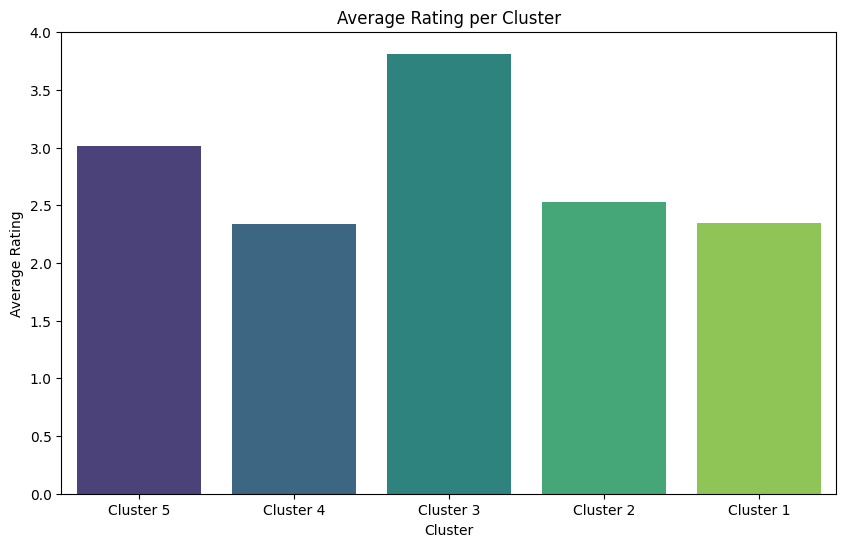

In [ ]:
# Plot average rating per cluster
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster_name', y='rating', data=df, ci=None, palette='viridis')
plt.title('Average Rating per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Rating')
plt.show()

In [ ]:
# Function to recommend restaurants in the same cluster
def recommend_restaurants(restaurant_name, n=5):
    if restaurant_name not in df['name'].values:
        return "Restaurant not found in dataset."

    cluster = df[df['name'] == restaurant_name]['cluster'].values[0]
    recommendations = df[df['cluster'] == cluster].sample(n)
    return recommendations[['name', 'cuisines', 'rating']]

# Example: Recommend similar restaurants to "Burger King"
print("\nRecommendations for 'Burger King':")
print(recommend_restaurants("Burger King"))


Recommendations for 'Burger King':
                    name                   cuisines  rating
3910       Cakes & Bakes          Bakery, Fast Food     2.9
3062           Pizza Hut  Italian, Pizza, Fast Food     3.5
8023    Halal Pizza Star           Pizza, Fast Food     0.0
4077     Starve Stalkers         Italian, Fast Food     0.0
7784  Green Tea Fanatics       Beverages, Fast Food     3.4


In [ ]:
!pip install plotly
import plotly.express as px
fig = px.scatter(df, x='rating', y='votes', color='cluster_name', hover_data=['name'])
fig.show()